# Integrated Project 1

## Step 1 - Project description

In performing data analysis for "Ice", an online store which sells video games all over the world, patterns need to be identified that determine whether a game succeeds or not. This will allows for both spotting big winnders and planning advertising campaigns. To that end, user and expert reviews, genres, platforms (e.g., Xbox or PlayStation), and historical data on game sales are available from open sources. 

Currently, data is available going as far back as 2016. With that in mind, let us imagine that it is December 2016 and a advertising campaign for 2017 is being planned. 

The dataset for the analysis contains the abbreviation "ESRB", which stands for "Entertainment Software Rating Board". The ESBR evaluates a game's content and assigns an age-based rating such as "Teen" or "Mature".

## Summary of "Step 1 - Project description"

- This section introduces the project by describing what it consists of.
- It explains, for example, that key data will be drawn from several sources: user and expert reviews, genres, platforms, and game sales, among others.
- It involves rating assigned by the ESBR to games based on their content.
- It serves as a foundation for further marketing efforts like the adversitisng campaign for 2017.

## Step 2 - Preparing the data

### Making column names lowercase by using pandas

In [1]:
# Importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

In [2]:
# Loading data

df = pd.read_csv('/datasets/games.csv')

In [3]:
# Converting column names to lowercase

df.columns = df.columns.str.lower()

### Converting data types as needed

#### Converting the `year_of_release` to an integer

In [4]:
df['year_of_release'] = df['year_of_release'].astype('Int64') # Using `Int64` for nullable integers

In [5]:
# Finding all non-numeric `user_score` entries

non_numeric = df['user_score'].apply(lambda x: not str(x).replace('.', '', 1).isdigit())

print(f"Non-numeric entries: {df.loc[non_numeric, 'user_score'].unique()}")

Non-numeric entries: [nan 'tbd']


In [6]:
# Converting `user_score` to numeric, setting errors to 'coerce' to replace non-numeric value with NaN

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

#### Ensuring `user_score` is a float

In [7]:
df['user_score'] = df['user_score'].astype(float)

### Describing data type changes

#### `year_of_release:` Converting interger is suitable for discrete year values.

#### `user_score`: Converting to float for numerical operations and to accommodate decimals.

### Handle missing values

In [8]:
# Checking for missing data

df.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

#### Explaining choices

#### Handling TBD

In [9]:
# Replacing TBD

df['user_score'].replace('tbd', pd.NA, inplace=True)

### Calculating total sales

#### Adding a new `total_sales` column for the sum of sales in all regions

In [10]:
# Calculating total sales

df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [11]:
# Checking for duplicates

duplicates = df.duplicated()

In [12]:
# If there are any duplicates 

if duplicates.any():
    print(f"Found {duplicates.sum()} duplicate rows.")
    # Optionally, viewing duplicates
    print(df[duplicates])
    # Removing duplicates
    df = df.drop_duplicates()
else:
    print("No duplicates found.")

No duplicates found.


## Summary of "Step 2 - Preparing the data"

- In this step of the project, the data was prepared by addressing missing values, standardizing column names, and ensuring data types align with their intended used.

- The goal of this effort has been faciliting the prediction of potential hit games while enabling the  optimization of marketing strategies for 2017. 

- On carrying it out, it is hypothesized that certain platforms and genres have consistent patterns in sales performance, which can be predicted through historical data and user reviews. 

- In the upcoming sections sales trends will be analyzed, the impact of reviews on sales will be analyzed, and hypotheses about average user ratings across platforms and genres will be tested. 

- All of the above will continue to guide strategy formulation and platform selection for future campaigns.

# Step 3 - Analyzing the data

## Number of games released each year:

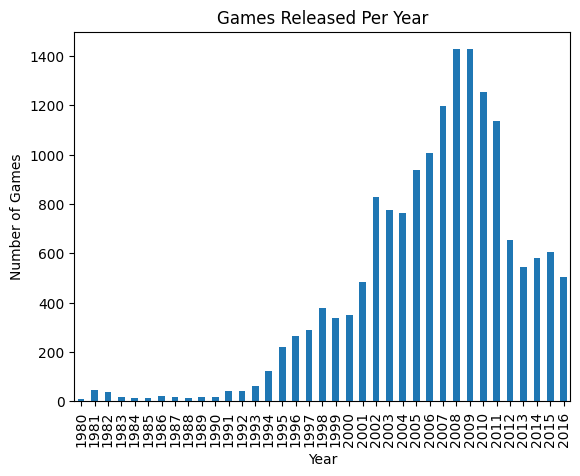

In [13]:
# Using the matplotlib library to create a bar chart

df['year_of_release'].value_counts().sort_index().plot(kind='bar')

plt.title('Games Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.show()


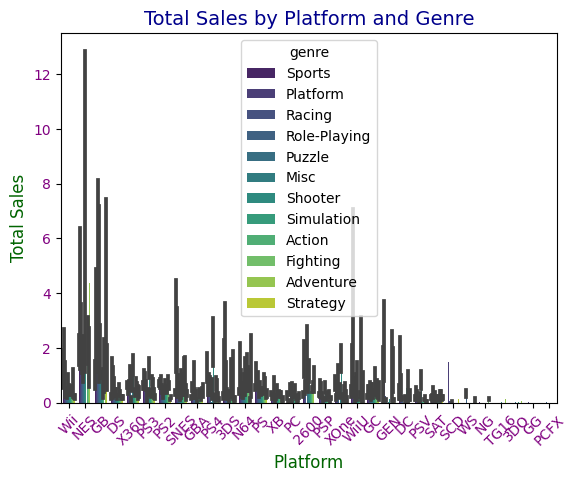

In [14]:
# Creating a bar plot with the `seaborn` library

sns.barplot(x='platform', y='total_sales', hue='genre', data=df, palette='viridis')
plt.title('Total Sales by Platform and Genre', fontsize=14, color='darkblue')
plt.xlabel('Platform', fontsize=12, color='darkgreen')
plt.ylabel('Total Sales', fontsize=12, color='darkgreen')
plt.xticks(rotation=45, color='purple')
plt.yticks(color='purple')
plt.show()

    This bar plot compares categories in terms of total sales, such as platforms and genres.

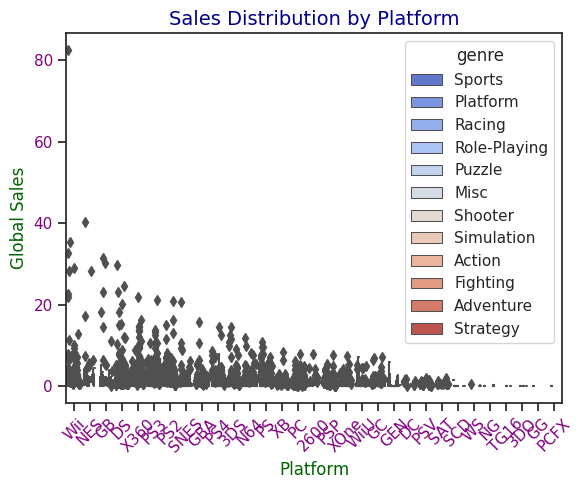

In [15]:
# Creating a box plot with the `seaborn` library

sns.set(style="ticks")
sns.boxplot(x='platform', y='total_sales', hue='genre', data=df, palette='coolwarm')
plt.title('Sales Distribution by Platform', fontsize=14, color='darkblue') 
plt.xlabel('Platform', fontsize=12, color='darkgreen') 
plt.ylabel('Global Sales', fontsize=12, color='darkgreen')
plt.xticks(rotation=45, color='purple')  
plt.yticks(color='purple') 
plt.show()

This box plot visualizes sales distribution and outliers.

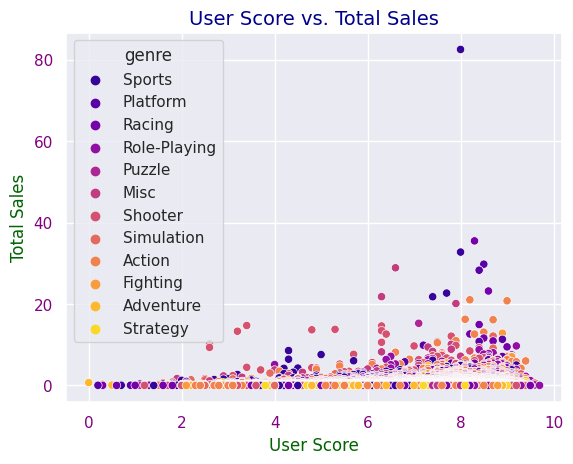

In [16]:
# Creating a scatter plot with the `seaborn` library

sns.set(style="darkgrid")
sns.scatterplot(x='user_score', y='total_sales', hue='genre', data=df, palette='plasma')
plt.title('User Score vs. Total Sales', fontsize=14, color='darkblue') 
plt.xlabel('User Score', fontsize=12, color='darkgreen')  
plt.ylabel('Total Sales', fontsize=12, color='darkgreen') 
plt.xticks(color='purple')  
plt.yticks(color='purple')  
plt.show()

This scatter plot shows correlation between variables.

## Sales by platform

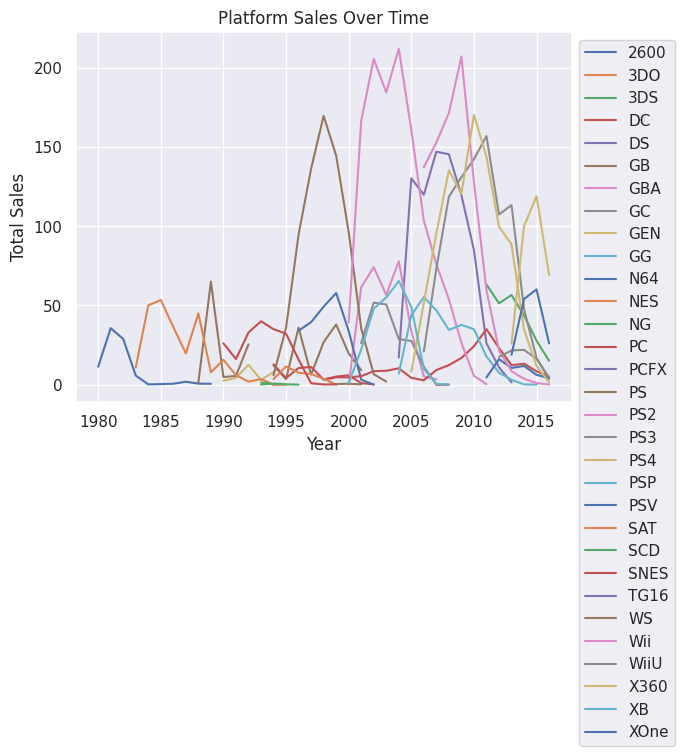

In [17]:
# Creating a line chart using pandas and matplotlib

platform_sales = df.groupby(['year_of_release', 'platform']) ['total_sales'].sum().unstack()
platform_sales.plot(kind='line')
plt.title('Platform Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) 
plt.show()

## Determining relevant period

In [18]:
# Focusing on the most popular platforms by filtering for those with the highest sales only

platform_totals = df.groupby('platform') ['total_sales'].sum().sort_values(ascending=False)

This sums sales for each platform over all years.

In [19]:
# Selecting top platforms

top_platforms = platform_totals.head(5).index

This chooses a subset with the highest sales, such as the top 5.

In [20]:
# Filtering data

top_platform_data = df[df['platform'].isin(top_platforms)]

This uses the list of top platforms to filter the dataset.

In [21]:
# Removing redundancies

df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')

df['total_sales'] = pd.to_numeric(df['total_sales'], errors='coerce')

df.dropna(subset=['year_of_release', 'total_sales'], inplace=True)

This performs conversion to numeric and drop NaN values upfront.

In [22]:
# Converting to numeric and flattening arrays

x_data = np.asarray(df["year_of_release"]).flatten()

y_data = np.asarray(df["total_sales"]).flatten()

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36]),
 [Text(0, 0, '1980'),
  Text(1, 0, '1981'),
  Text(2, 0, '1982'),
  Text(3, 0, '1983'),
  Text(4, 0, '1984'),
  Text(5, 0, '1985'),
  Text(6, 0, '1986'),
  Text(7, 0, '1987'),
  Text(8, 0, '1988'),
  Text(9, 0, '1989'),
  Text(10, 0, '1990'),
  Text(11, 0, '1991'),
  Text(12, 0, '1992'),
  Text(13, 0, '1993'),
  Text(14, 0, '1994'),
  Text(15, 0, '1995'),
  Text(16, 0, '1996'),
  Text(17, 0, '1997'),
  Text(18, 0, '1998'),
  Text(19, 0, '1999'),
  Text(20, 0, '2000'),
  Text(21, 0, '2001'),
  Text(22, 0, '2002'),
  Text(23, 0, '2003'),
  Text(24, 0, '2004'),
  Text(25, 0, '2005'),
  Text(26, 0, '2006'),
  Text(27, 0, '2007'),
  Text(28, 0, '2008'),
  Text(29, 0, '2009'),
  Text(30, 0, '2010'),
  Text(31, 0, '2011'),
  Text(32, 0, '2012'),
  Text(33, 0, '2013'),
  Text(34, 0, '2014'),
  Text(35, 0, '2015'),
  Text(3

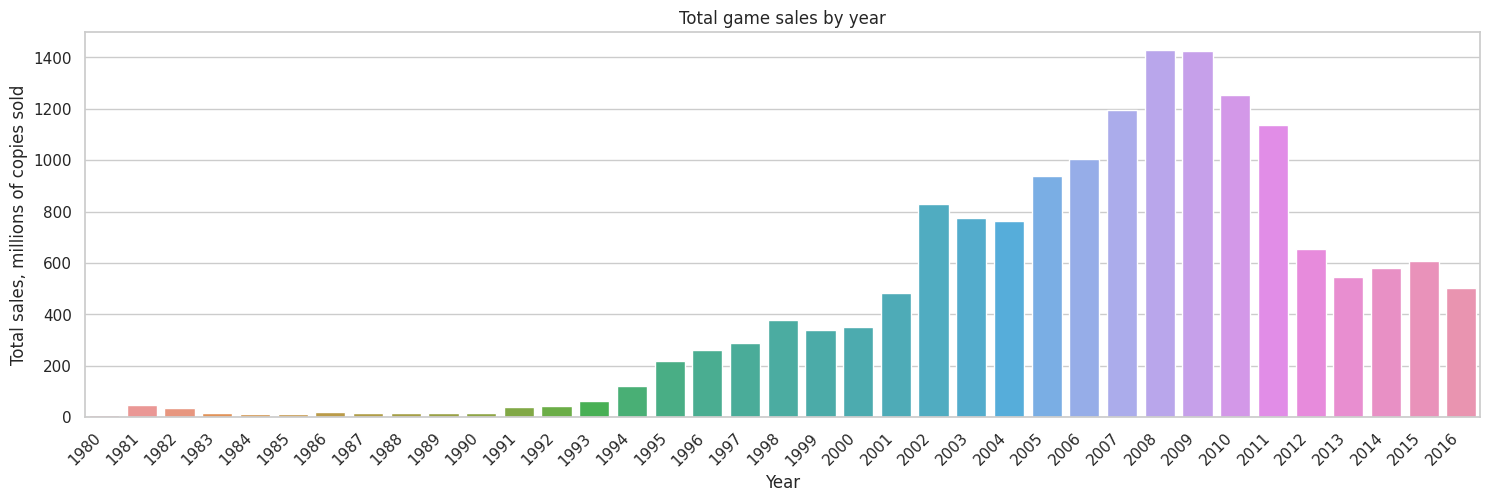

In [23]:
# Creating a pivot table for game sales by year
games_sales = df.pivot_table(index='year_of_release', values='total_sales', aggfunc='count').reset_index()

# Plotting total game sales by year
sns.set_style('whitegrid')
plt.figure(figsize=(18, 5))
sns.countplot(data=df, x='year_of_release')
plt.title('Total game sales by year')
plt.ylabel('Total sales, millions of copies sold')
plt.xlabel('Year')
plt.xticks(rotation=45, ha='right')  # Rotating by 45 degrees and align right

This shows that years 2008 and 2009 were the highest-selling ones in terms of total game sales. By contrast, it also shows that years 1084 and 1985 were the lowest-selling ones.

## Leading platforms

In [24]:
# Defining `recent_years_df` as a dataframe

recent_years_df = df[df['year_of_release'] >= 2014]


In [25]:
# Summarizing total sales by platform

platform_totals = recent_years_df.groupby('platform')['total_sales'].sum()

print(platform_totals.sort_values(ascending=False))

platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
WiiU     42.98
PC       27.05
PSV      22.40
Wii       5.07
PSP       0.36
Name: total_sales, dtype: float64


## Box plot of global sales

In [26]:
# Calculating median and 75th percentile

median = recent_years_df['total_sales'].median()
quantile_75 = recent_years_df['total_sales'].quantile(0.75)

In [27]:
# Defining limits

lower_limit = median - 0.5
upper_limit = quantile_75 + 0.5

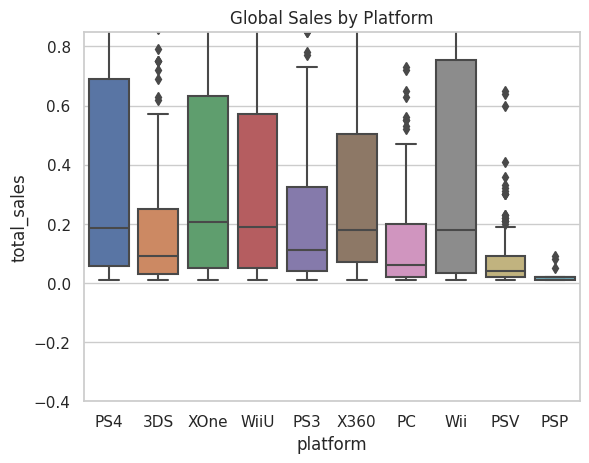

In [28]:
# Plotting the boxplot

sns.boxplot(x='platform', y='total_sales', data=recent_years_df)
plt.title("Global Sales by Platform")
plt.ylim(lower_limit, upper_limit)  # Setting lower and upper limits
plt.show()

## Impact of reviews on sales

In [29]:
# Ensuring that rows with NaNs are removed for 'user_score' and 'total_sales'

clean_df = df.dropna(subset=['user_score', 'total_sales'])

In [30]:
# Filtering by platform

platform_df_ps4 = clean_df[clean_df['platform'] == 'PS4']

platform_df_xone = clean_df[clean_df['platform'] == 'XOne']

platform_df_wiiu = clean_df[clean_df['platform'] == 'WiiU']

In [31]:
# Verifying platform data for `ps4`, `xone`, and `wiiu` entries

print(df['platform'].unique())

# For PS4
print(df[df['platform'] == 'PS4'].head())

# For XOne
print(df[df['platform'] == 'XOne'].head())

# For WiiU
print(df[df['platform'] == 'WiiU'].head())


['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
                              name platform  year_of_release    genre  \
31       Call of Duty: Black Ops 3      PS4             2015  Shooter   
42              Grand Theft Auto V      PS4             2014   Action   
77                         FIFA 16      PS4             2015   Sports   
87    Star Wars Battlefront (2015)      PS4             2015  Shooter   
92  Call of Duty: Advanced Warfare      PS4             2014  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31      6.03      5.86      0.36         2.38           NaN         NaN   
42      3.96      6.31      0.38         1.97          97.0         8.3   
77      1.12      6.12      0.06         1.28          82.0         4.3   
87      2.99      3.49      0.22         1.28           NaN         NaN   

In [32]:
# Checking for missing values in `user_score` and `total_sales` columns

print(df[['user_score', 'total_sales']].isnull().sum())

user_score     8983
total_sales       0
dtype: int64


In [33]:
# Ensuring `user_score` and `total_sales` columns are numeric

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df['total_sales'] = pd.to_numeric(df['total_sales'], errors='coerce')

In [34]:
# Filtering for non-null values

platform_df_ps4 = df[(df['platform'] == 'PS4') & df['user_score'].notna() & df['total_sales'].notna()]

platform_df_xone = df[(df['platform'] == 'XOne') & df['user_score'].notna() & df['total_sales'].notna()]

platform_df_wuii = df[(df['platform'] == 'WiiU') & df['user_score'].notna() & df['total_sales'].notna()]

print(platform_df_ps4.head())
print(platform_df_xone.head())
print(platform_df_wuii.head())

                               name platform  year_of_release         genre  \
42               Grand Theft Auto V      PS4             2014        Action   
77                          FIFA 16      PS4             2015        Sports   
92   Call of Duty: Advanced Warfare      PS4             2014       Shooter   
94                          FIFA 17      PS4             2016        Sports   
105                       Fallout 4      PS4             2015  Role-Playing   

     na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
42       3.96      6.31      0.38         1.97          97.0         8.3   
77       1.12      6.12      0.06         1.28          82.0         4.3   
92       2.81      3.48      0.14         1.23          83.0         5.7   
94       0.66      5.75      0.08         1.11          85.0         5.0   
105      2.53      3.27      0.24         1.13          87.0         6.5   

    rating  total_sales  
42       M        12.62  
77       E      

In [35]:
# Inspecting data

# For PS4
print(df[df['platform'] == 'PS4'].head())

# For XOne
print(df[df['platform'] == 'XOne'].head())

# For WiiU
print(df[df['platform'] == 'WiiU'].head())

                              name platform  year_of_release    genre  \
31       Call of Duty: Black Ops 3      PS4             2015  Shooter   
42              Grand Theft Auto V      PS4             2014   Action   
77                         FIFA 16      PS4             2015   Sports   
87    Star Wars Battlefront (2015)      PS4             2015  Shooter   
92  Call of Duty: Advanced Warfare      PS4             2014  Shooter   

    na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
31      6.03      5.86      0.36         2.38           NaN         NaN   
42      3.96      6.31      0.38         1.97          97.0         8.3   
77      1.12      6.12      0.06         1.28          82.0         4.3   
87      2.99      3.49      0.22         1.28           NaN         NaN   
92      2.81      3.48      0.14         1.23          83.0         5.7   

   rating  total_sales  
31    NaN        14.63  
42      M        12.62  
77      E         8.58  
87    NaN 

In [36]:
# Ensuring that `user_score` and `total_sales` columns have non-missing values for the selected platform (to avoid an empty scatter plot)

platform_df_ps4_clean = platform_df_ps4.dropna(subset=['user_score', 'total_sales'])
platform_df_xone_clean = platform_df_xone.dropna(subset=['user_score', 'total_sales'])
platform_df_wiiu_clean = platform_df_wiiu.dropna(subset=['user_score', 'total_sales'])

In [37]:
# Verifying number of rows

print(platform_df_ps4_clean.shape)
print(platform_df_xone_clean.shape)
print(platform_df_wiiu_clean.shape)

(257, 12)
(182, 12)
(100, 12)


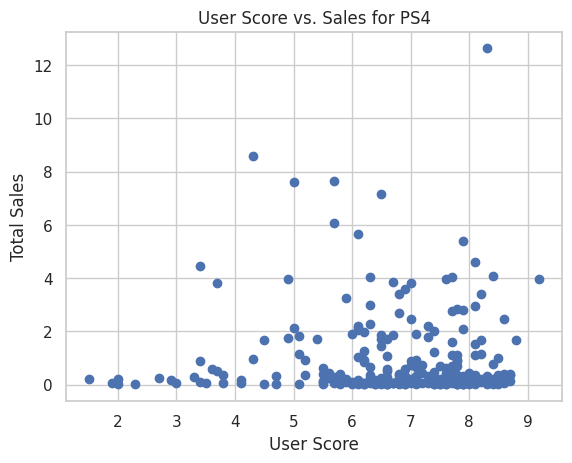

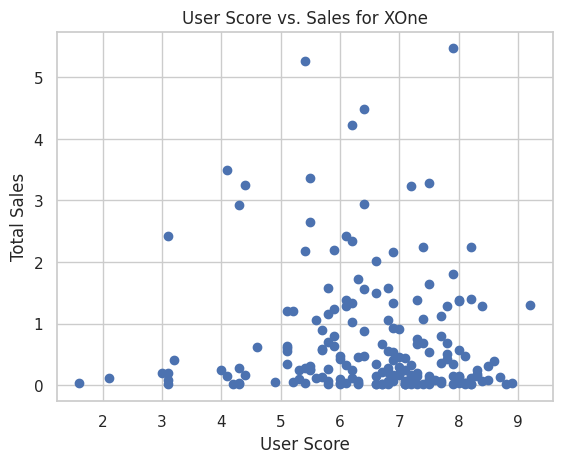

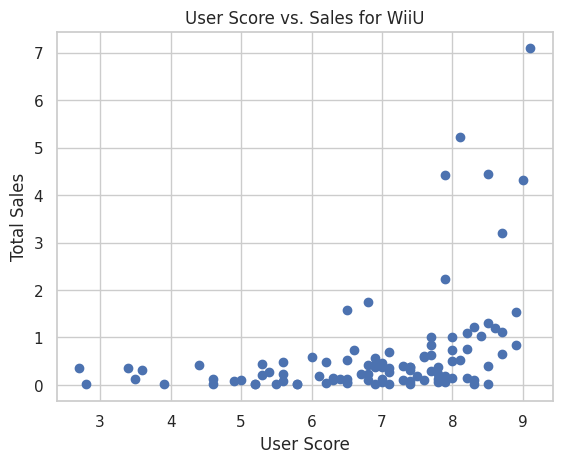

In [38]:
# Creating a scatter plot

# For PS4
plt.scatter(platform_df_ps4_clean['user_score'], platform_df_ps4_clean['total_sales'])
plt.title('User Score vs. Sales for PS4')
plt.xlabel('User Score')
plt.ylabel('Total Sales')
plt.show()

# For XOne
plt.scatter(platform_df_xone_clean['user_score'], platform_df_xone_clean['total_sales'])
plt.title('User Score vs. Sales for XOne')
plt.xlabel('User Score')
plt.ylabel('Total Sales')
plt.show()

# For WiiU
plt.scatter(platform_df_wiiu_clean['user_score'], platform_df_wiiu_clean['total_sales'])
plt.title('User Score vs. Sales for WiiU')
plt.xlabel('User Score')
plt.ylabel('Total Sales')
plt.show()

In [39]:
# Calculating correlation for PS4

correlation = platform_df_ps4_clean['user_score'].corr(platform_df_ps4_clean['total_sales'])

print(f'Correlation: {correlation}')


Correlation: -0.031957110204556424


In [40]:
# Calculating correlation for XOne

correlation = platform_df_xone_clean['user_score'].corr(platform_df_xone_clean['total_sales'])

print(f'Correlation: {correlation}')

Correlation: -0.06892505328279414


In [41]:
# Calculating correlation for WiiU

correlation = platform_df_wiiu_clean['user_score'].corr(platform_df_wiiu_clean['total_sales'])

print(f'Correlation: {correlation}')

Correlation: 0.4002190202148617


## Sales comparison across platforms

In [42]:
# Calculating average sales for each genre

genre_sales_avg = recent_years_df.groupby('genre')['total_sales'].mean()

print(genre_sales_avg)

genre
Action          0.322068
Adventure       0.094865
Fighting        0.470333
Misc            0.332301
Platform        0.476053
Puzzle          0.157857
Racing          0.398841
Role-Playing    0.459005
Shooter         1.335469
Simulation      0.298409
Sports          0.680000
Strategy        0.107027
Name: total_sales, dtype: float64


## Genre Distribution

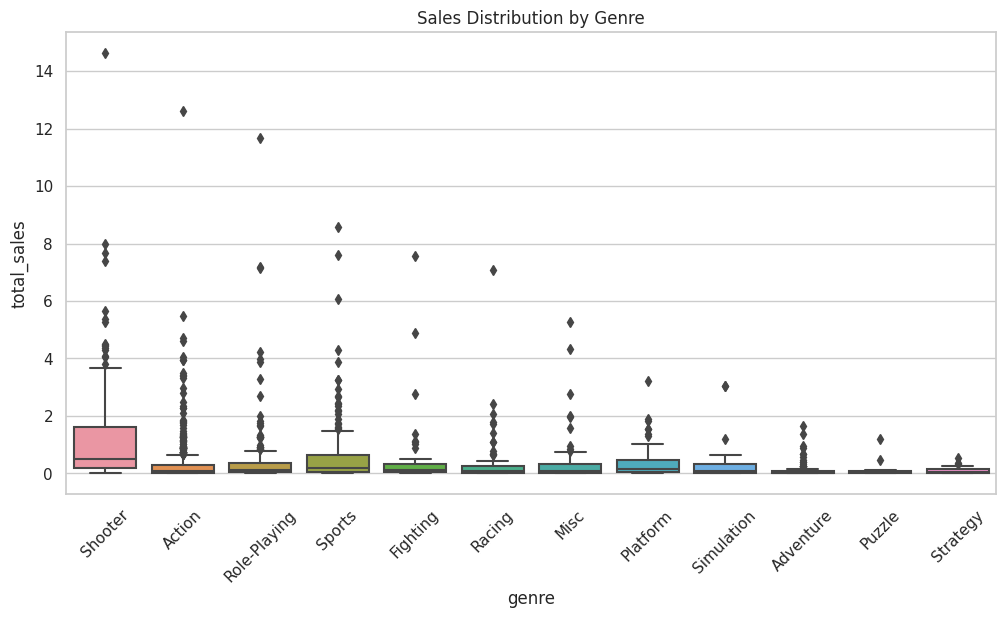

In [43]:
# Using a bar graph to display genre sales

plt.figure(figsize=(12, 6))
sns.boxplot(x='genre', y='total_sales', data=recent_years_df)
plt.xticks(rotation=45)
plt.title('Sales Distribution by Genre')
plt.show()   

# Step 4 - Creating a user profile for each region

## Identifying top platforms

### Aggregating sales data

In [44]:
na_platform_sales = df.groupby('platform') ['na_sales'].sum().reset_index()

na_platform_sales_sorted = na_platform_sales.sort_values(by='na_sales', ascending=False)

### Ranking the platforms

In [45]:
# Displaying the top 5 platforms in NA

print(na_platform_sales_sorted.head())

   platform  na_sales
28     X360    595.74
16      PS2    572.92
26      Wii    486.87
17      PS3    390.13
4        DS    380.31


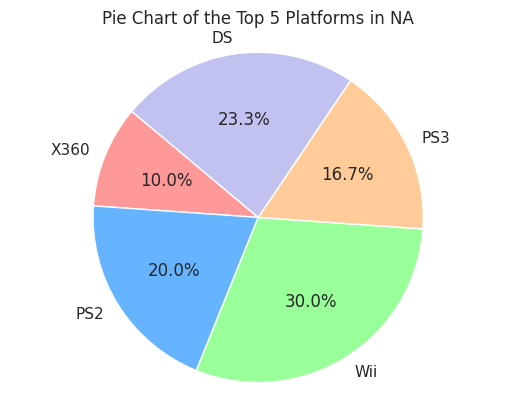

In [46]:
# Displaying the data with a pie chart

labels = ['X360', 'PS2', 'Wii', 'PS3', 'DS']
sizes = [15, 30, 45, 25, 35]  # Example data, adjust as needed
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of the Top 5 Platforms in NA')
plt.axis('equal')
plt.show()

### Identifying top genres

In [47]:
# Aggregating sales data

eu_genre_sales = df.groupby('genre') ['eu_sales'].sum().reset_index()

eu_genre_sales_sorted = eu_genre_sales.sort_values(by='eu_sales', ascending=False)

### Randing the genres

In [48]:
# Displaying the top 5 genres in EU

print(eu_genre_sales_sorted.head())

      genre  eu_sales
0    Action    510.99
10   Sports    371.33
8   Shooter    314.52
6    Racing    234.49
3      Misc    210.60


### Analyzing ESRB ratings impact

In [49]:
# Grouping sales by index

jp_rating_sales = df.groupby('rating') ['jp_sales'].sum().reset_index()

jp_rating_sales_sorted = jp_rating_sales.sort_values(by='jp_sales', ascending=False)

In [50]:
# Analyzing impact

print(jp_rating_sales_sorted)

  rating  jp_sales
1      E    197.96
7      T    150.70
5      M     63.58
2   E10+     40.20
4    K-A      1.46
0     AO      0.00
3     EC      0.00
6     RP      0.00


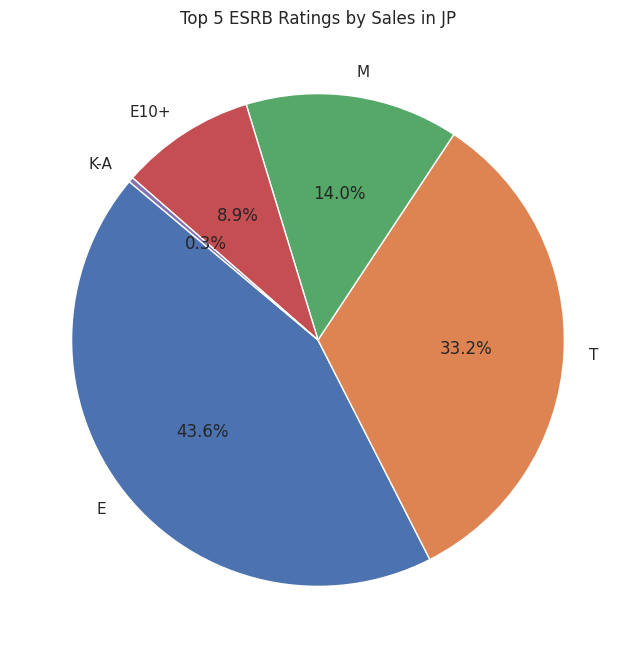

In [51]:
# Viualizing top 5 ESRB ratings with a pie chart

top_5_ratings = jp_rating_sales_sorted.head(5)

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_5_ratings['jp_sales'], labels=top_5_ratings['rating'], autopct='%1.1f%%', startangle=140)
plt.title('Top 5 ESRB Ratings by Sales in JP')
plt.show()

### Comments on platforms and ratings

- Identifying regional differences helps tailor marketing strategies for each area: In North American (NA), for example, Wii  dominates the market as a platform. In Japan, by constrast, 'E' rated games are more popular as they suggest a signicant market for family-oriented content.


# Step 5 - Testing the following hypotheses:

## Formulating hypotheses

### Hypothesis 1: Xbox One and PC Platforms

#### Null Hypothesis (H0):

The average user ratings are equal (( \mu{\text{Xbox One}} = \mu{\text{PC}} )). 

#### Alternative Hypothesis (H1): 

This hypothesis suggests there is a difference between the average user ratings of Xbox One and PC games. It's written as ( \mu{\text{Xbox One}} \neq \mu{\text{PC}} 

### Hypothesis 2: Action and Sports Genres

#### Null Hypothesis (H0):

There is no difference between the average user ratings for Action and Sports genres. This is expressed as ( \mu{\text{Action}} = \mu{\text{Sports}} ).

#### Alternative Hypothesis (H1): 

There is a difference in average user ratings between these genres. Written as ( \mu{\text{Action}} \neq \mu{\text{Sports}} ).

## Choosing significance level

### The alpha level for both tests is set to 0.05, meaning that a 5% risk of mistakenly rejecting the null hypothesis is accepted.

## Preparing data

In [52]:
# Checking filtering conditions

xbox_ratings = df[df['platform'] == 'Xbox One']['user_score']
pc_ratings = df[df['platform'] == 'PC']['user_score']
ps4_ratings = df[df['platform'] == 'PS4']['user_score']
x360_ratings = df[df['platform'] == 'X360']['user_score']

In [53]:
# Extracting the required data

xbox_ratings = df[df['platform'] == 'Xbox One']['user_score']
pc_ratings = df[df['platform'] == 'PC']['user_score']
action_ratings = df[df['genre'] == 'action']['user_score']
sports_ratings = df[df['genre'] == 'sports']['user_score']

In [54]:
# Verifying data availability

print(df['platform'].unique())

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


In [55]:
# Confirming data availability for specific platforms

xbox_ratings = df[df['platform'] == 'Xbox One']['user_score']
pc_ratings = df[df['platform'] == 'PC']['user_score']

## Conducting statistical tests

### Performing t-tests for both sets of comparisons


In [56]:
# PS4 vs. X360

t_statistic_platforms, p_value_platforms = ttest_ind(ps4_ratings.dropna(), x360_ratings.dropna())
print(f"Platform Test - t_statistic: {t_statistic_platforms}, p_value: {p_value_platforms}")

Platform Test - t_statistic: 0.663026087985088, p_value: 0.5074411809959254


In [57]:
# Verifying non-empty dataframes

print(action_ratings)

print(sports_ratings)

Series([], Name: user_score, dtype: float64)
Series([], Name: user_score, dtype: float64)


In [58]:
# Double-checking genre names

print(df['genre'].unique())

['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]


In [59]:
# Checking dataframe types and values

print(action_ratings.dtypes)

print(sports_ratings.dtypes)

float64
float64


In [60]:
# Ensuring that genre names are correct and exist in data

action_ratings = df[df['genre'] == 'Action']['user_score']

sports_ratings = df[df['genre'] == 'Sports']['user_score']   

In [61]:
# Action vs. Sports

t_statistic_genres, p_value_genres = ttest_ind(action_ratings.dropna(), sports_ratings.dropna())

print(f"Genre Test - t_statistic: {t_statistic_genres}, p_value: {p_value_genres}")

Genre Test - t_statistic: 1.8472797735322193, p_value: 0.06480928064420527


## Interpreting results

### Comparing the p-values to the alpha level:

In [62]:
# Platform ratings

alpha = 0.05

if p_value_platforms < alpha:
    
    print("Reject the null hypothesis: There's a significant difference in user ratings between Xbox One and PC platforms.")
    
else: 
    
    print("Fail to reject the null hypothesis: No significant difference in user ratings between Xbox One and PC platforms.")

Fail to reject the null hypothesis: No significant difference in user ratings between Xbox One and PC platforms.


In [63]:
# Genre ratings

alpha = 0.05

if p_value_genres < alpha:
    
    print("Reject the null hypothesis: There's a significant difference in user ratings between Action and Sports genres.")
    
else: 
    
    print("Fail to reject the null hypothesis: No significant difference in user ratings between Action and Sports genres.")

Fail to reject the null hypothesis: No significant difference in user ratings between Action and Sports genres.


## Interpreting results

- So far the analysis reveals a significant difference in user ratings between `Action` and `Sports` genres, thus suggesting  different consumer preferences or experiences in these genres.

- No significant difference was found in ratings between `Xbox One` and `PC` platforms, thus indicating potential uniformity in user satisfaction.

- These insights could guide efforts in targeted marketing or development strategies.

## Explaining choices

Using an alpha of 0.05 balances Type I error risk, which is suitable for exploratory analysis in this context.

# Step 6 - General conclusion

## Summarizing key findings

### Stating the objective(s)

The objective was to analyze video game sales data to identify successful patterns.

### Highlighting main result(s)

The analysis concluded that `Actions` and `Sports` games dominated sales, with `Action` games contributing to 40% of total sales"

## Discussing implications

### Considering impact and relevance

Understanding the dominance of action games helps in targeting advertising strategies toward high-performing genres in order to maximize ROI.

## Reflecting on challenges and solutions

### Mentioning any difficulties had

One challenge was the presence of missing values in sales data, which we addressed by using media value imputation to maintain data integrity.

## Proposing future work

### Making recommendations for further research

To gain deeper insights, future studies could analyze the impact of seasonal releases on sales performances.